In [6]:
import sys
print(sys.executable)


/opt/homebrew/opt/python@3.11/bin/python3.11


In [7]:
import sys
!{sys.executable} -m pip install yfinance


203.25s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached yfinance-1.1.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-3.19.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached charset_normalizer-3.4.4-cp311-cp311-macosx_10_9_universal2.whl.metadata (37 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
Using cached yfinance-1.1.0-py2.py3-none-any.

In [1]:
import yfinance as yf


In [ ]:
%pip install numpy pandas matplotlib tensorflow scikit-learn


  Using cached tensorflow-2.20.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (4.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.15.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (3.0 kB)
  Using cach

In [3]:
import yfinance as yf

df = yf.download("TSLA", start="2015-01-01", end="2024-01-01")
df.to_csv("TSLA.csv")
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [4]:
import pandas as pd

df = pd.read_csv("TSLA.csv")
df.head()


,Price,Close,High,Low,Open,Volume
0,Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,14.620667457580566,14.883333206176758,14.21733283996582,14.857999801635742,71466000
3,2015-01-05,14.005999565124512,14.433333396911621,13.810667037963867,14.303333282470703,80527500
4,2015-01-06,14.085332870483398,14.279999732971191,13.61400032043457,14.003999710083008,93928500


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2266 non-null   str  
 1   Close   2265 non-null   str  
 2   High    2265 non-null   str  
 3   Low     2265 non-null   str  
 4   Open    2265 non-null   str  
 5   Volume  2265 non-null   str  
dtypes: str(6)
memory usage: 106.3 KB


In [6]:
df.describe()


,Price,Close,High,Low,Open,Volume
count,2266,2265,2265,2265,2265,2265
unique,2266,2220,2156,2175,2164,2255
top,Ticker,14.005999565124512,13.41866683959961,12.333333015441895,24.0,85084500
freq,1,3,3,4,4,2


In [16]:
df = df.loc[:, ~df.columns.duplicated()]
df.columns


Index(['Date', 'Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [19]:
df['Close'] = df['Close'].astype(str)


In [20]:
df['Close'] = df['Close'].str.replace(',', '', regex=False)


In [22]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')


In [23]:
df = df.dropna(subset=['Close'])


In [24]:
df['Close'].dtype


dtype('float64')

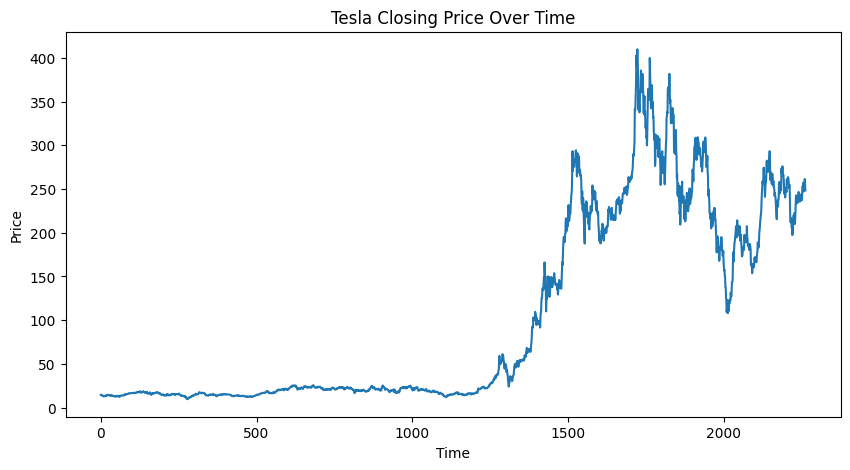

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'].values)
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


In [26]:
data = df[['Close']].values


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


In [29]:
import numpy as np

X = []
y = []
window_size = 60

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [32]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)


In [34]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0101
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014
Epoch 13/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010
Epoch 14/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011
Epoch 15/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012
Epoc

In [35]:
predictions = model.predict(X_test)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [36]:
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y_test.reshape(-1,1))


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

rmse = math.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)


RMSE: 21.08067304782236
MAE: 17.281419905405198


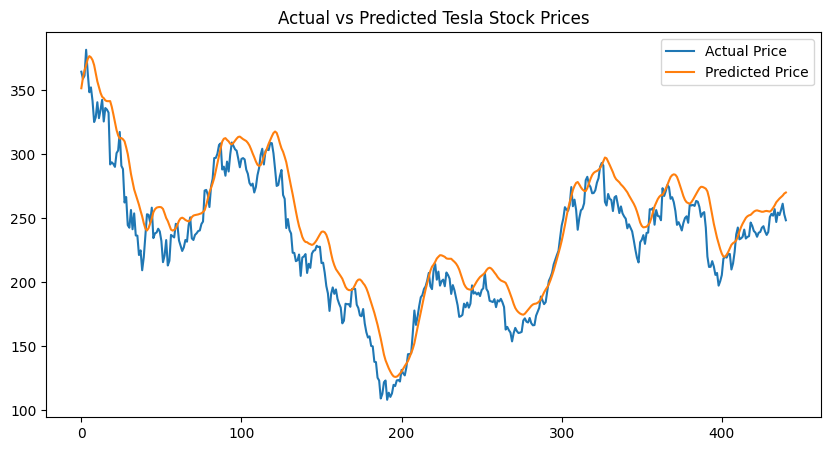

In [38]:
plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.legend()
plt.title("Actual vs Predicted Tesla Stock Prices")
plt.show()
